In [13]:
# Convolution layers AND Filters

In [14]:
# Convolution Operations, Filters and Feature Maps

# Convolution Operation:
    # Mathematical operation where a small matrix (kernel or filter) slides over the input images to extract features like edges, textures, or patterns.

# Key concepts:
    # Kernel(Filter):
        # -A small matrix (eg 3x3) used to extract features from the input image.
        # -Each elemnet of the kernel is a weight learned during training 
    
    # Feature Map:
        # -Output of the convolution operation.
        # -Each feature map is a 2D array of values representing the presence of a particular feature in the input image.
        # -Highlights specific patterns detected by the filter.

    # Channels:
        # -For RGB images, convolution processes each color channel (Red, Green, Blue) separately and combines results.
        # -Each channel is processed with its own set of filters.

        

In [15]:
# Concepts of kernel size, Stride, and Padding

# Kernel Size:
    # -the dimensions of the filter (eg 3x3 3x3, 5x5 5x5)
    # -Smaller Kernels: capture fine details
    # -Larger Kernels: Detect broader features

# Stride:
    # -Defines the step size of the filter as it slides across the input
    # -Largers strides: Reduces the feature map size, improving computation efficiency
    # -Smaller Strides: Retain more details but increases computation

# Padding:
    # -Adds Extra Pixels around the input to control the size of the outptut 
    # -Valid Padding: NO padding; the feature map shrinks
    # -Same padding: Adds enough padding to keep the output size equal to the input size

In [16]:
# Visualizing how Convolution Extracts Features

# Edge Detection:
    # -Kernels like sobel or Prewitt highliht edges in images

# Feature extraction:
    # -Initial layers focus on edges; deeper layer capture abstract patterns.

In [17]:
# Exercise Objective:
    # Understand Convolution operations by implementing and visualizing their effects using tensorflow  and PyTorch
    

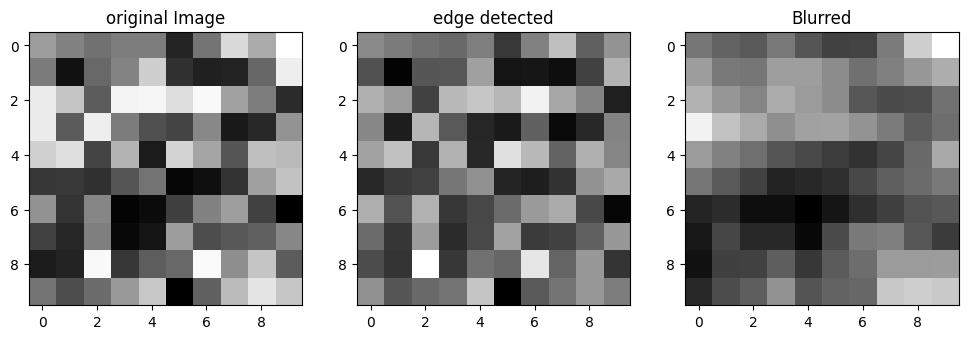

In [18]:
import matplotlib.pyplot as plt
import numpy as np  
from scipy.ndimage import convolve # it is imported to perform convolution operations

#  load a sample grayscale image
image = np.random.rand(10, 10) #it generates a 10x10 random grayscale values b/w 0 and 1 to simulate

# print(image)

# Define Convolution Kernels(filters)
edge_detection_kernels = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
# edge_detection_kernels is a 3x3 kernal for detecting edges in the images by emphasizing high contrast areas
])

blur_kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) / 9
# these is a 3x3 kernel used for blurring the images by averaging the pixel value in a neighborhood.
    # by diving it by 9, it normalizes the kernels so that sum of all the elements equals to 1, ensuring the brightness remains consistent


# Apply convolution
# convolve image kernel applies the convolution operation on the image using the specified kernel
edge_detection_image = convolve(image, edge_detection_kernels)
blured_image = convolve(image, blur_kernel)


# Visualize the original and filter images
# sided by side visualization of images with 1 row and 3 colums
    # -fiure size of 12 ich wide and 4 inch height
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("original Image")

axes[1].imshow(edge_detection_image, cmap="gray")
axes[1].set_title("edge detected")

axes[2].imshow(blured_image, cmap="gray")
axes[2].set_title("Blurred")
plt.show()

In [19]:
# implment convolution using Tensorflow
import tensorflow as tf

# create a sample input tensor(batch_size, height, width, channels)
image_tensor = tf.random.normal([1, 10, 10, 1])

# define a convolutional layer
conv_layer = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(3,3),
    strides=(1,1),
    padding='same'
)

# Applying Convoltion
output_tensor = conv_layer(image_tensor)

print(f"original shape:{image_tensor.shape}")
print(f"output shape:{output_tensor.shape}")



original shape:(1, 10, 10, 1)
output shape:(1, 10, 10, 1)


In [20]:
# Tensorflow example
conv_layer_large_kernel = tf.keras.layers.Conv2D(filters=1, kernel_size=(5,5), strides=(1,1), padding='same')

# applying convoulution
output_large_kernel = conv_layer_large_kernel(image_tensor)

print(f"original shape:{image_tensor.shape}")
print(f"large kernel output shape:{output_large_kernel.shape}")



original shape:(1, 10, 10, 1)
large kernel output shape:(1, 10, 10, 1)


In [21]:
# implment convolution using Pytorch
import torch
import torch.nn as nn

# create a sample input tensor (batch_size, channel, height, width)
image_tensor_pt = torch.rand([1, 1, 10, 10])

# define a convolutional layer
conv_layer = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=1,
    padding=1
)

# Applying Convoltion
output_tensor_pt = conv_layer(image_tensor_pt)

print(f"original shape:{image_tensor_pt.shape}")
print(f"output shape:{output_tensor_pt.shape}")



original shape:torch.Size([1, 1, 10, 10])
output shape:torch.Size([1, 1, 10, 10])


In [23]:
# PyTorch example
conv_layer_stride_2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=2, padding=1)

# applying convoulution
output_stride_2 = conv_layer_stride_2(image_tensor_pt)

print(f"original shape:{image_tensor_pt.shape}")
print(f"stride output shape:{output_stride_2.shape}")

original shape:torch.Size([1, 1, 10, 10])
stride output shape:torch.Size([1, 1, 5, 5])
